## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import joblib

from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from rdkit_and_test_functions import (
    smiles_to_3d,
    extract_3d_features,
    prepare_test_data_modified
)

In [2]:
X_train = joblib.load("X_train_modified.pkl")
y_train = joblib.load("y_train_modified.pkl")

print("X_train_modified shape:", X_train.shape)
print("y_train_modified shape:", y_train.shape)

X_train_modified shape: (25093, 11)
y_train_modified shape: (25093,)


## Xgboost

In [12]:
xgb_model = XGBRegressor(
    subsample=0.8,
    reg_lambda=1,
    reg_alpha=0,
    n_estimators=500,
    min_child_weight=1,
    max_depth=10,
    learning_rate=0.01,
    gamma=0,
    colsample_bytree=0.6,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=0, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.01, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=10, max_leaves=None,
             min_child_weight=1, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

In [8]:
X_test, y_test, test_smiles = prepare_test_data_modified(
    X_train.columns
)

X column names:
smiles

y column name:
electrochemical_gap
X_test shape: (132, 11)
y_test shape: (132,)


In [13]:
y_pred = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("HOPV15 Results")
print("----------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

HOPV15 Results
----------------
MAE : 0.22517761960197494
RMSE: 0.30686327758953375
R²  : 0.22602172486514527


In [14]:
results = pd.DataFrame({
    "SMILES": test_smiles,
    "Experimental_Gap": y_test,
    "Predicted_Gap": y_pred,
    "Absolute_Error": np.abs(y_test - y_pred)
})

results.to_csv("HOPV15_predictions_xgboost_modified.csv", index=False)

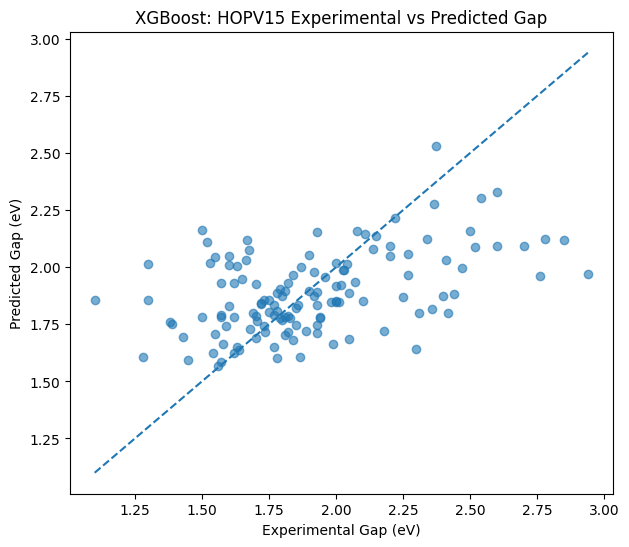

In [15]:
plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Experimental Gap (eV)")
plt.ylabel("Predicted Gap (eV)")
plt.title("XGBoost: HOPV15 Experimental vs Predicted Gap")

plt.show()